In [1]:
# 03 - Descriptive Statistics

"""This notebook performs descriptive statistical analysis on e-commerce price data.

Main objectives:
- Compute central tendency measures: mean and median
- Compute dispersion measures: standard deviation, variance, range, IQR
- Analyze price distributions by website and category
- Study price volatility using time-series observations
- Visualize key descriptive patterns"""

'This notebook performs descriptive statistical analysis on e-commerce price data.\n\nMain objectives:\n- Compute central tendency measures: mean and median\n- Compute dispersion measures: standard deviation, variance, range, IQR\n- Analyze price distributions by website and category\n- Study price volatility using time-series observations\n- Visualize key descriptive patterns'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
PROJECT_ID = "price-intel-prod"
DATASET_ID = "price_staging"

client = bigquery.Client(project=PROJECT_ID)

query_clean = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.clean_prices`
"""

query_ts = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.price_timeseries`
"""

df_clean = client.query(query_clean).to_dataframe()
df_ts = client.query(query_ts).to_dataframe()

df_clean["scraped_at"] = pd.to_datetime(df_clean["scraped_at"])
df_ts["scraped_at"] = pd.to_datetime(df_ts["scraped_at"])

c:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\Usuario\Desktop\analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [4]:
#Overall descriptive statistics of the price

price_descriptive_stats = {
    "count": df_clean["price"].count(),
    "mean": df_clean["price"].mean(),
    "median": df_clean["price"].median(),
    "min": df_clean["price"].min(),
    "max": df_clean["price"].max(),
    "range": df_clean["price"].max() - df_clean["price"].min(),
    "variance": df_clean["price"].var(),
    "std_dev": df_clean["price"].std(),
    "q1": df_clean["price"].quantile(0.25),
    "q3": df_clean["price"].quantile(0.75),
    "iqr": df_clean["price"].quantile(0.75) - df_clean["price"].quantile(0.25),
}

price_descriptive_stats

{'count': np.int64(10523),
 'mean': np.float64(1801.6698527036017),
 'median': np.float64(979.0),
 'min': np.float64(15.0),
 'max': np.float64(39999.0),
 'range': np.float64(39984.0),
 'variance': np.float64(8827423.689770449),
 'std_dev': np.float64(2971.0980612848257),
 'q1': np.float64(149.0),
 'q3': np.float64(1940.0),
 'iqr': np.float64(1791.0)}

In [5]:
price_stats_df = pd.DataFrame(
    price_descriptive_stats.items(),
    columns=["metric", "value"]
)

price_stats_df

,metric,value
0,count,1.052300e+04
1,mean,1.801670e+03
2,median,9.790000e+02
3,min,1.500000e+01
4,max,3.999900e+04
5,range,3.998400e+04
6,variance,8.827424e+06
7,std_dev,2.971098e+03
8,q1,1.490000e+02
9,q3,1.940000e+03


In [6]:
#Statistics by site

price_by_site = df_clean.groupby("site_name")["price"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max",
    std_dev="std",
    variance="var"
).reset_index()

price_by_site

,site_name,count,mean,median,min,max,std_dev,variance
0,electroplanet,585,7584.261538,5999.0,39.0,39999.0,6536.267487,4.272279e+07
1,jumia_ma,9938,1461.277808,959.0,15.0,19275.0,2179.873377,4.751848e+06


In [7]:
#Statistics by category

price_by_category = df_clean.groupby("category")["price"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max",
    std_dev="std",
    variance="var"
).reset_index().sort_values("mean", ascending=False)

price_by_category

,category,count,mean,median,min,max,std_dev,variance
10,pc-gamer,46,18585.760870,13999.0,9999.0,39999.0,10188.970964,1.038151e+08
17,ultrabook,27,17332.333333,17999.0,13999.0,19999.0,2541.955637,6.461538e+06
6,macbook,36,12687.916667,8999.0,7999.0,20590.0,5596.075841,3.131606e+07
11,pc-hybride,30,11999.000000,11999.0,9999.0,13999.0,2034.190511,4.137931e+06
7,notebook,111,8896.216216,9499.0,3690.0,12999.0,2149.255306,4.619298e+06
2,ecran,131,5086.305344,2599.0,849.0,15999.0,4465.699752,1.994247e+07
13,tablettes-android,170,3751.635294,2749.0,1590.0,11490.0,2120.917920,4.498293e+06
14,tablettes-tactiles,1123,3353.933482,2525.0,79.0,18999.0,2908.191243,8.457576e+06
16,telephones-smartphones,2711,2367.658539,1499.0,114.0,19275.0,2671.144032,7.135010e+06
9,ordinateurs-pc,840,1821.078571,1399.0,339.0,7399.0,1309.385347,1.714490e+06


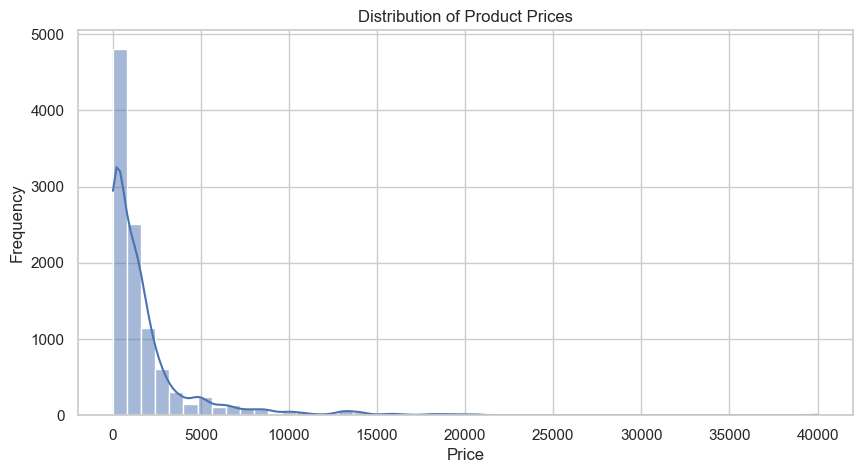

In [8]:
#Price Histogram

plt.figure(figsize=(10, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

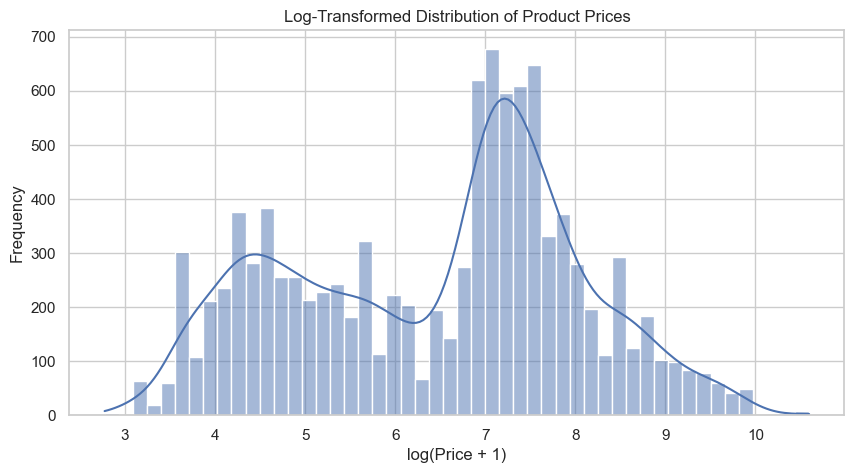

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df_clean["price"]), bins=50, kde=True)
plt.title("Log-Transformed Distribution of Product Prices")
plt.xlabel("log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

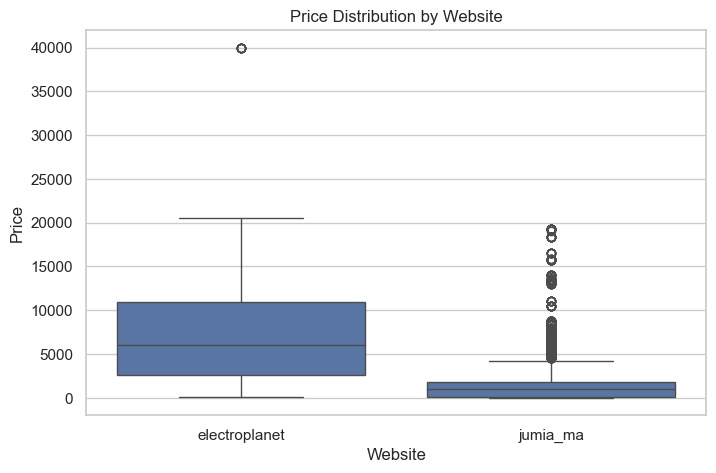

In [10]:
#Boxplot per site

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="site_name", y="price")
plt.title("Price Distribution by Website")
plt.xlabel("Website")
plt.ylabel("Price")
plt.show()

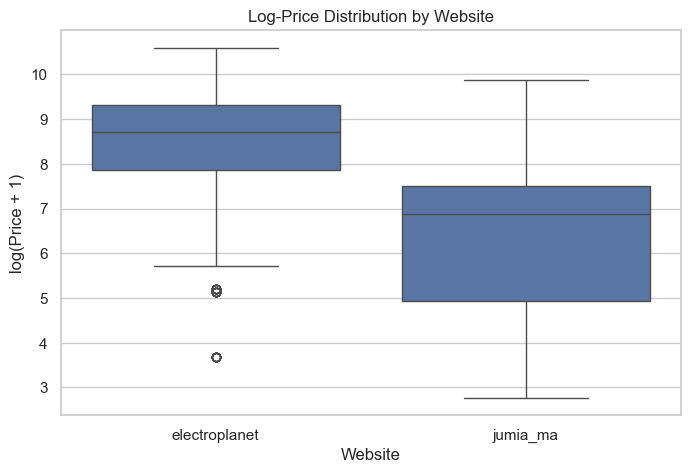

In [11]:
df_clean["log_price"] = np.log1p(df_clean["price"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="site_name", y="log_price")
plt.title("Log-Price Distribution by Website")
plt.xlabel("Website")
plt.ylabel("log(Price + 1)")
plt.show()

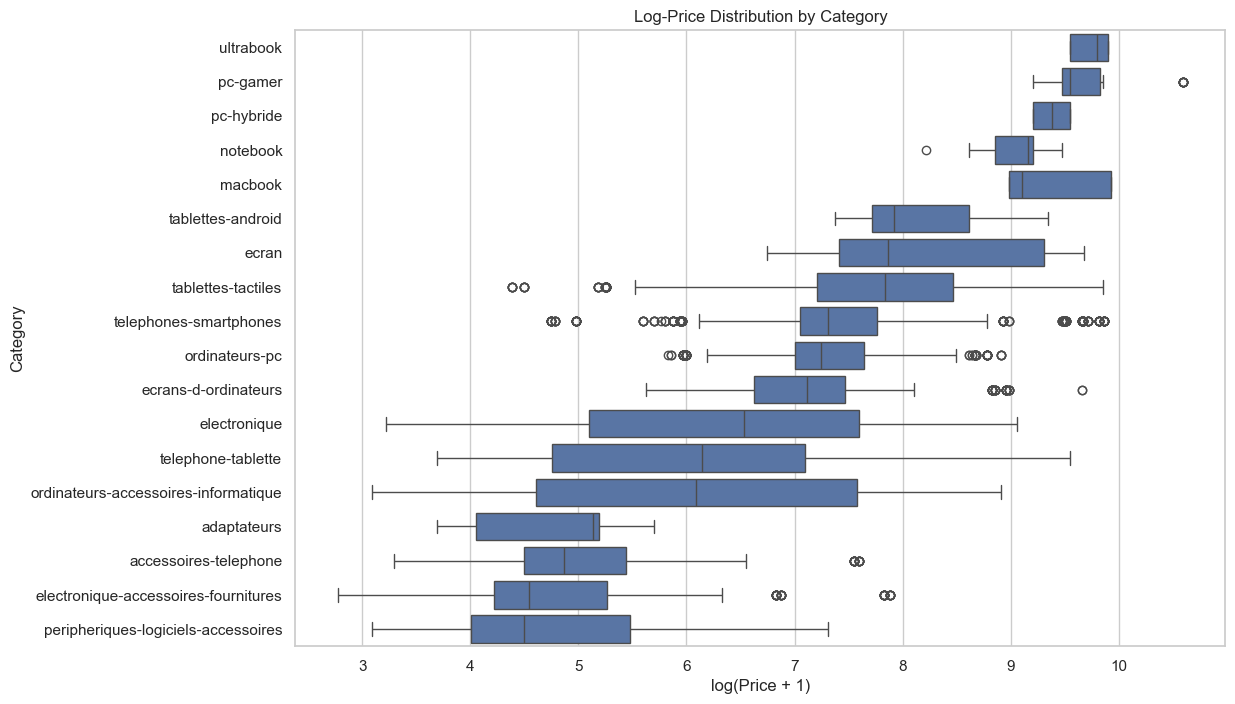

In [12]:
#Boxplot per category

df_clean["log_price"] = np.log1p(df_clean["price"])

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_clean,
    y="category",
    x="log_price",
    order=df_clean.groupby("category")["price"].median().sort_values(ascending=False).index
)
plt.title("Log-Price Distribution by Category")
plt.xlabel("log(Price + 1)")
plt.ylabel("Category")
plt.show()

In [14]:
#Volatility per product

price_volatility = df_ts.groupby(["product_id", "product_name", "site_name", "category"])["price"].agg(
    nb_observations="count",
    mean_price="mean",
    std_price="std",
    min_price="min",
    max_price="max"
).reset_index()

price_volatility["price_range"] = price_volatility["max_price"] - price_volatility["min_price"]

price_volatility

,product_id,product_name,site_name,category,nb_observations,mean_price,std_price,min_price,max_price,price_range
0,ELECTRO-01EB89FF,"LS49FG910EUXEN 49""MONITEURODYSSEY G9 G91F SAMSUNG",electroplanet,ecran,1,11999.000000,NaN,11999.0,11999.0,0.0
1,ELECTRO-04677085,MSI-THIN-B12VE 15.6 I7-13620H 16GB 512G RTX4050,electroplanet,pc-gamer,1,15999.000000,NaN,15999.0,15999.0,0.0
2,ELECTRO-04E8FF5F,TABLETTE MATEPAD T8 LTE 2GB+32GB BLEU HUAWEI,electroplanet,tablettes-android,2,1590.000000,0.000000,1590.0,1590.0,0.0
3,ELECTRO-058A8739,"VIVOBOOK I9-13900H 31E 16-1T SSD W11 15"" SLV ASUS",electroplanet,notebook,2,12999.000000,0.000000,12999.0,12999.0,0.0
4,ELECTRO-05A85AE1,TAB X816 S9+ 12G/256G GRAPHITE SAMSUNG,electroplanet,tablettes-android,1,11490.000000,NaN,11490.0,11490.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1069,JUMIA-FEFE662D,Oppo Reno15 F 5G - 12GB + 512 GB - 50MP Selfie...,jumia_ma,telephones-smartphones,27,4899.000000,0.000000,4899.0,4899.0,0.0
1070,JUMIA-FF23350B,"Hp ProDisplay P202 - Écran LED - 20"" (20"" Pouc...",jumia_ma,ecrans-d-ordinateurs,17,675.470588,30.195442,599.0,699.0,100.0
1071,JUMIA-FF53BF7A,"Adaptateur USB Type-C 8 Ports, avec USB Ports,...",jumia_ma,peripheriques-logiciels-accessoires,13,99.000000,0.000000,99.0,99.0,0.0
1072,JUMIA-FFEB8557,Sac PC Portable Mallette Portable Cartable Sac...,jumia_ma,ordinateurs-accessoires-informatique,3,78.000000,0.000000,78.0,78.0,0.0


In [22]:
#Top most volatile products


top_volatile_products = price_volatility[
    price_volatility["nb_observations"] >= 3
].sort_values("std_price", ascending=False).head(10)

top_volatile_products

,product_id,nb_observations,mean_price,std_price,min_price,max_price,price_range
334,JUMIA-40FF6592,3,1933.000000,982.072808,799.0,2500.0,1701.0
265,JUMIA-2B83016E,9,2711.111111,579.750904,2100.0,3200.0,1100.0
57,ELECTRO-AA62C810,11,7362.636364,504.524979,6999.0,7999.0,1000.0
558,JUMIA-88984620,23,18814.434783,491.856023,18312.0,19275.0,963.0
527,JUMIA-7CD0730B,17,16062.529412,419.536816,15722.0,16549.0,827.0
766,JUMIA-CABBFD1F,27,6021.592593,375.203971,5700.0,6499.0,799.0
180,JUMIA-154EE05D,25,13691.440000,354.129341,13300.0,13999.0,699.0
455,JUMIA-68E82EA6,18,10663.500000,275.395598,10450.0,10999.0,549.0
598,JUMIA-95675BA1,25,4659.000000,238.047614,4499.0,4999.0,500.0
563,JUMIA-8A4BD620,23,4984.782609,229.839263,4750.0,5200.0,450.0


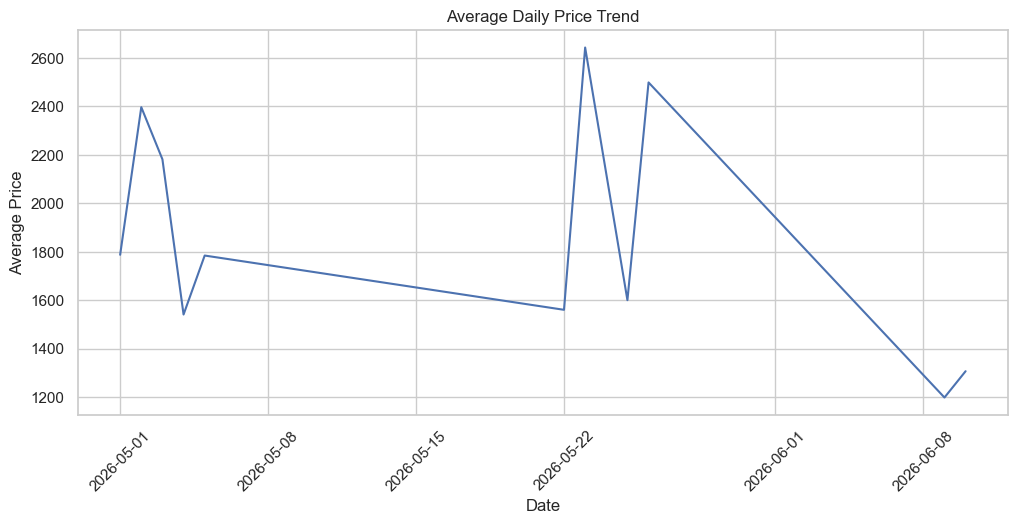

In [23]:
#Average price over time

daily_price_trend = df_ts.groupby(df_ts["scraped_at"].dt.date)["price"].mean().reset_index()
daily_price_trend.columns = ["date", "avg_price"]

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_price_trend, x="date", y="avg_price")
plt.title("Average Daily Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [24]:
#Final Summary

descriptive_summary = {
    "mean_price": df_clean["price"].mean(),
    "median_price": df_clean["price"].median(),
    "std_price": df_clean["price"].std(),
    "min_price": df_clean["price"].min(),
    "max_price": df_clean["price"].max(),
    "most_expensive_category_by_mean": price_by_category.iloc[0]["category"],
    "highest_mean_price": price_by_category.iloc[0]["mean"],
    "most_represented_site": df_clean["site_name"].value_counts().idxmax()
}

descriptive_summary

{'mean_price': np.float64(1801.6698527036017),
 'median_price': np.float64(979.0),
 'std_price': np.float64(2971.0980612848257),
 'min_price': np.float64(15.0),
 'max_price': np.float64(39999.0),
 'most_expensive_category_by_mean': 'pc-gamer',
 'highest_mean_price': np.float64(18585.760869565216),
 'most_represented_site': 'jumia_ma'}

In [26]:
# Price change distribution

price_change_stats = df_ts["price_change_pct"].describe()
price_change_stats

count    10523.000000
mean        -0.025088
std          2.288887
min        -68.040000
25%          0.000000
50%          0.000000
75%          0.000000
max         67.420000
Name: price_change_pct, dtype: float64

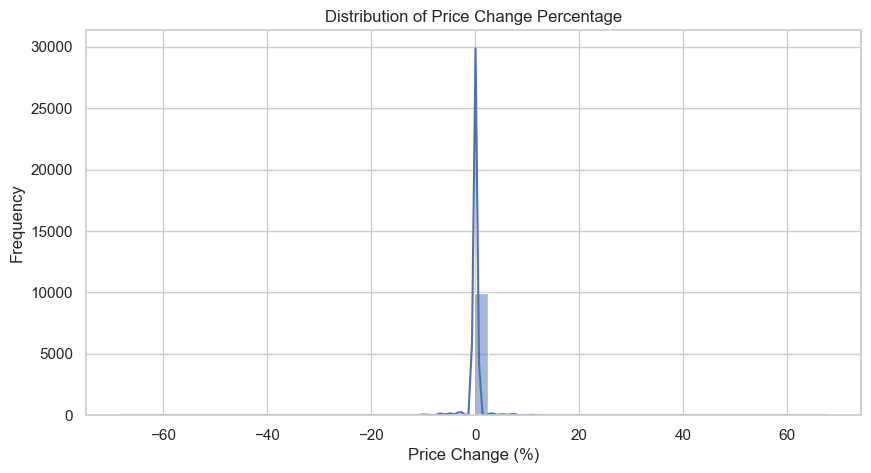

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df_ts["price_change_pct"].dropna(), bins=50, kde=True)
plt.title("Distribution of Price Change Percentage")
plt.xlabel("Price Change (%)")
plt.ylabel("Frequency")
plt.show()

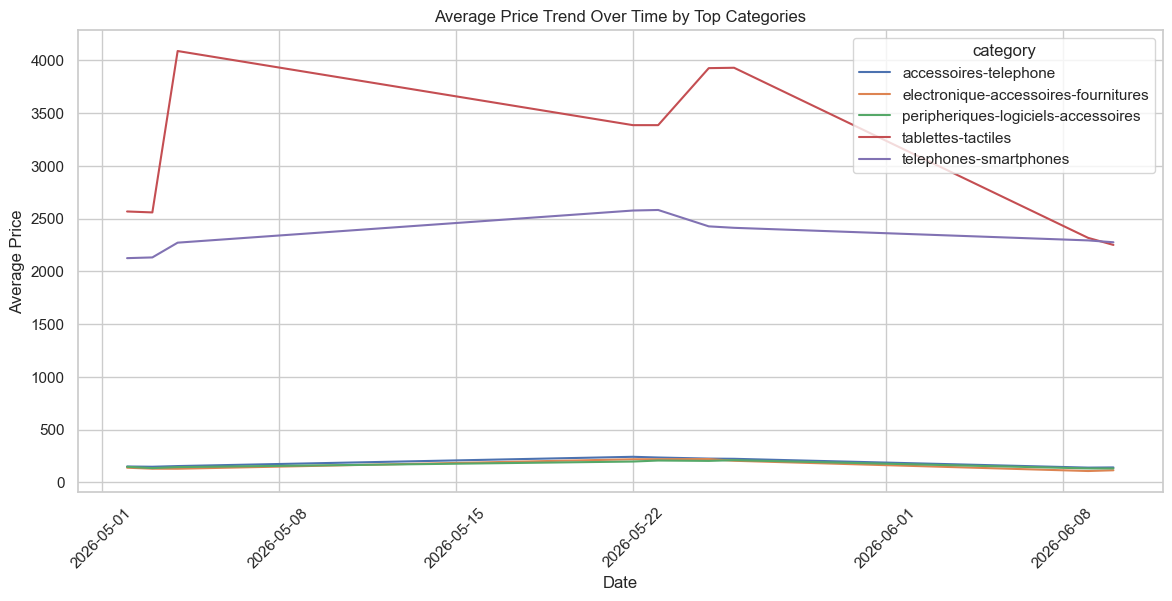

In [28]:
# Category trends over time

df_ts["date"] = df_ts["scraped_at"].dt.date

category_daily_trend = df_ts.groupby(["date", "category"])["price"].mean().reset_index()

top_categories = df_ts["category"].value_counts().head(5).index

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=category_daily_trend[category_daily_trend["category"].isin(top_categories)],
    x="date",
    y="price",
    hue="category"
)
plt.title("Average Price Trend Over Time by Top Categories")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

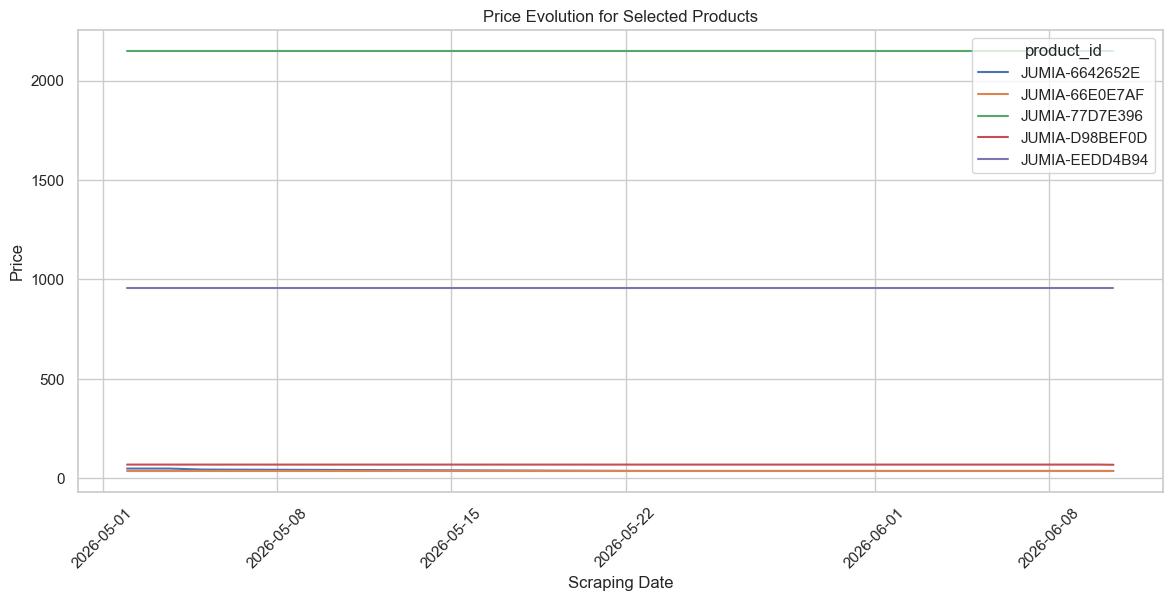

In [29]:
# Time-series plots for some products

products_with_many_points = (
    df_ts.groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sample_ts = df_ts[df_ts["product_id"].isin(products_with_many_points)]

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sample_ts,
    x="scraped_at",
    y="price",
    hue="product_id"
)
plt.title("Price Evolution for Selected Products")
plt.xlabel("Scraping Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

In [30]:
# Time-series plots for some products

df_ts = df_ts.sort_values(["product_id", "scraped_at"])

product_price_evolution = df_ts.groupby(
    ["product_id", "product_name", "site_name", "category"]
).agg(
    nb_observations=("price", "count"),
    first_price=("price", "first"),
    last_price=("price", "last"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    mean_price=("price", "mean"),
    std_price=("price", "std")
).reset_index()

product_price_evolution["price_range"] = (
    product_price_evolution["max_price"] - product_price_evolution["min_price"]
)

product_price_evolution["total_change_pct"] = (
    (product_price_evolution["last_price"] - product_price_evolution["first_price"])
    / product_price_evolution["first_price"]
) * 100


products_with_changes = product_price_evolution[
    (product_price_evolution["nb_observations"] >= 3) &
    (product_price_evolution["std_price"] > 0) &
    (product_price_evolution["price_range"] > 0)
].copy()

products_with_changes.sort_values("std_price", ascending=False).head(10)

,product_id,product_name,site_name,category,nb_observations,first_price,last_price,min_price,max_price,mean_price,std_price,price_range,total_change_pct
367,JUMIA-40FF6592,Projecteur HY300 1080P Full HD Home Cinéma VGA...,jumia_ma,electronique,3,2500.0,799.0,799.0,2500.0,1933.000000,982.072808,1701.0,-68.040000
286,JUMIA-2B83016E,Crelander Tablette PC T30 PRO avec Étui Rose...,jumia_ma,tablettes-tactiles,9,2100.0,3200.0,2100.0,3200.0,2711.111111,579.750904,1100.0,52.380952
57,ELECTRO-AA62C810,"ASUS VIVOBOOK M1502 15,6 R7 16GB 512 SSD W11 1Y",electroplanet,notebook,11,6999.0,7999.0,6999.0,7999.0,7362.636364,504.524979,1000.0,14.287755
632,JUMIA-88984620,Apple iPhone 17 Pro Max / 512GB / Orange Cosmi...,jumia_ma,telephones-smartphones,23,18312.0,19275.0,18312.0,19275.0,18814.434783,491.856023,963.0,5.258847
595,JUMIA-7CD0730B,Apple iPhone 17 Pro 512 GB - Bleu Intense - Sm...,jumia_ma,telephones-smartphones,17,16549.0,15722.0,15722.0,16549.0,16062.529412,419.536816,827.0,-4.997281
875,JUMIA-CABBFD1F,"Oppo RENO14- 6.59"" - 5G 12Go+512Go -AI Flash P...",jumia_ma,telephones-smartphones,27,6499.0,6499.0,5700.0,6499.0,6021.592593,375.203971,799.0,0.000000
189,JUMIA-154EE05D,Apple iPad Pro M5 (2025) 256 Go Wi-Fi Noir Écr...,jumia_ma,tablettes-tactiles,22,13999.0,13300.0,13300.0,13999.0,13649.500000,357.724655,699.0,-4.993214
509,JUMIA-68E82EA6,Apple iPad Pro M4 13-inch (2024) 256 Go Wi-Fi ...,jumia_ma,tablettes-tactiles,18,10450.0,10450.0,10450.0,10999.0,10663.500000,275.395598,549.0,0.000000
638,JUMIA-8A4BD620,Apple iPad A16 / 11e génération (2025) 11-inch...,jumia_ma,tablettes-tactiles,23,4750.0,5200.0,4750.0,5200.0,4984.782609,229.839263,450.0,9.473684
768,JUMIA-AC3E98E0,Apple iPad Air M3 11in (2025) Wi-Fi 128GB Mauv...,jumia_ma,tablettes-tactiles,18,8328.0,8328.0,8328.0,8766.0,8498.333333,219.714521,438.0,0.000000


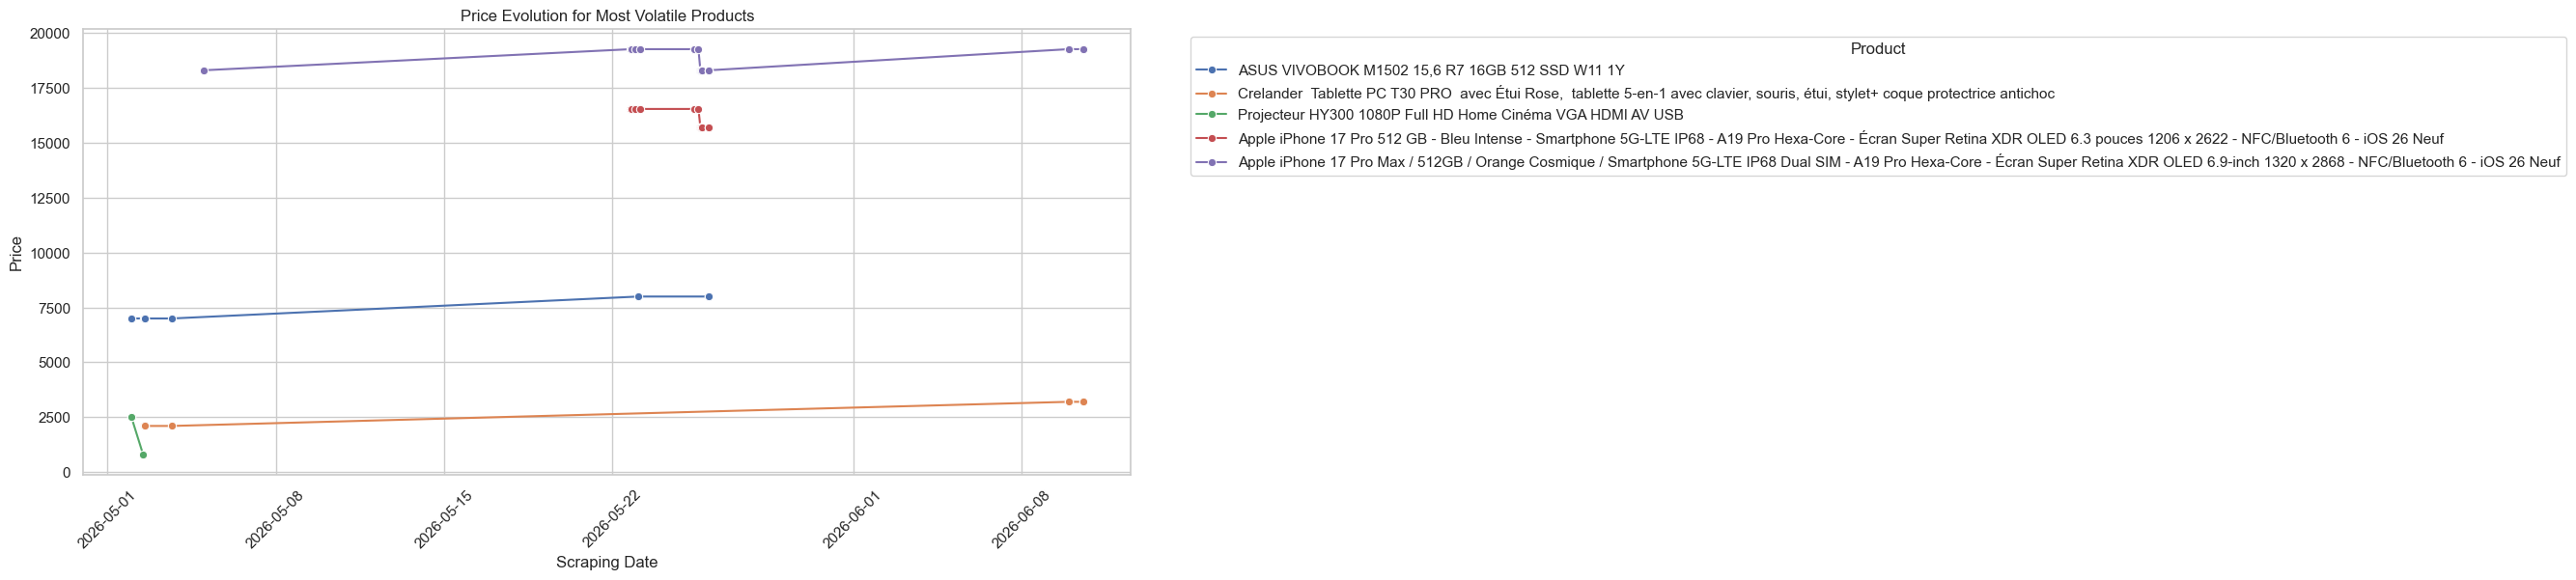

In [31]:
selected_products = (
    products_with_changes
    .sort_values("std_price", ascending=False)
    .head(5)["product_id"]
)

sample_ts = df_ts[df_ts["product_id"].isin(selected_products)]

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sample_ts,
    x="scraped_at",
    y="price",
    hue="product_name",
    marker="o"
)
plt.title("Price Evolution for Most Volatile Products")
plt.xlabel("Scraping Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

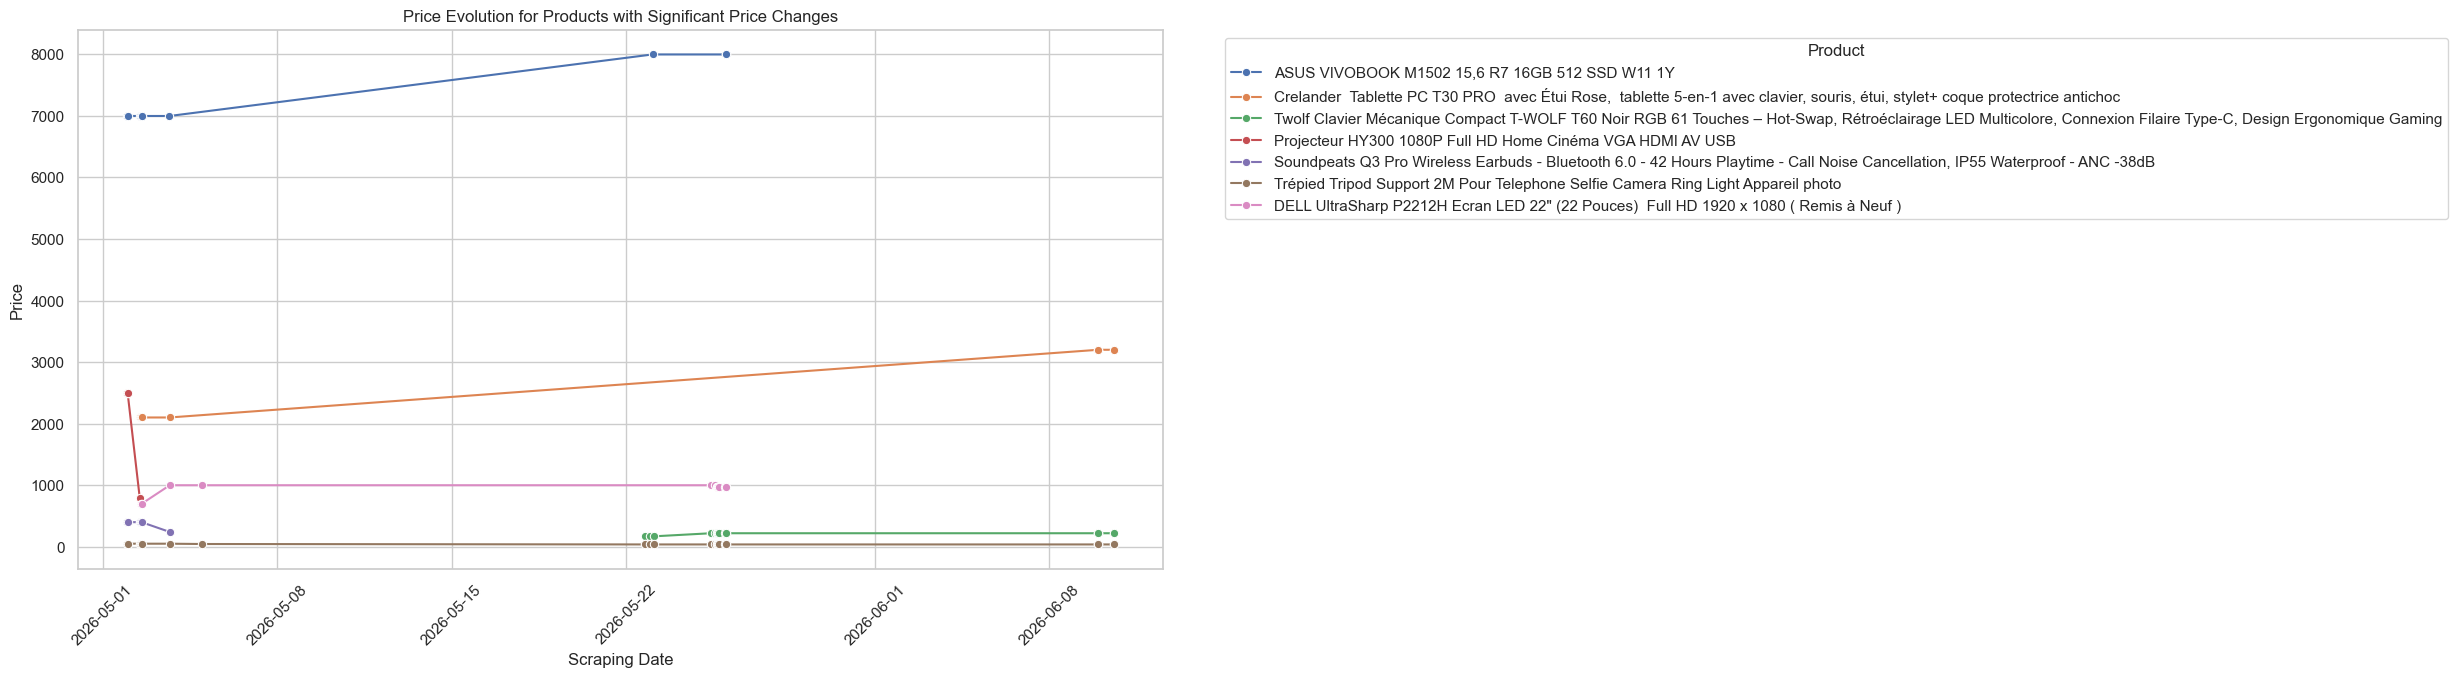

In [33]:
# Top 3 increases

top_increases = products_with_changes.sort_values(
    "total_change_pct",
    ascending=False
).head(3)

top_increases


# Top 3 decreases
top_decreases = products_with_changes.sort_values(
    "total_change_pct",
    ascending=True
).head(3)

top_decreases


# Top 3 volatility
top_volatility = products_with_changes.sort_values(
    "std_price",
    ascending=False
).head(3)

top_volatility


selected_products = pd.concat([
    top_increases,
    top_decreases,
    top_volatility
])["product_id"].drop_duplicates()

sample_ts = df_ts[df_ts["product_id"].isin(selected_products)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sample_ts,
    x="scraped_at",
    y="price",
    hue="product_name",
    marker="o"
)
plt.title("Price Evolution for Products with Significant Price Changes")
plt.xlabel("Scraping Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [34]:
#For time-series visualization, products were not selected only based on the number of observations. Products were selected based on both sufficient temporal coverage and actual price variation. Specifically, we retained products with at least three observations, non-zero standard deviation, and a positive price range. This ensures that the plotted products show meaningful price evolution rather than repeated identical prices.

In [25]:
#Markdown

"""The descriptive analysis shows that the dataset contains 10,523 price observations. The average product price is approximately 1,801.67 MAD, while the median price is 979 MAD. Since the mean is much higher than the median, the price distribution is right-skewed, meaning that a smaller number of expensive products increase the overall average.

The price range is very large, from 15 MAD to 39,999 MAD, with a standard deviation of approximately 2,971.10 MAD. This high dispersion indicates strong variability in product prices, which is expected because the dataset includes both low-cost accessories and high-end electronics such as gaming PCs, MacBooks, and ultrabooks.

By website, Electroplanet has a much higher average price than Jumia Morocco. Electroplanet’s average price is approximately 7,584.26 MAD, compared to 1,461.28 MAD for Jumia. The median price is also higher for Electroplanet, at 5,999 MAD compared to 959 MAD for Jumia. However, this comparison should be interpreted carefully because the number of observations is highly imbalanced: Jumia represents 9,938 observations, while Electroplanet represents only 585 observations.

At the category level, the most expensive categories are mainly computer-related products. The highest average price is observed in the `pc-gamer` category, with an average price of approximately 18,585.76 MAD, followed by `ultrabook`, `macbook`, `pc-hybride`, and `notebook`. In contrast, categories such as `adaptateurs`, `peripheriques-logiciels-accessoires`, and `electronique-accessoires-fournitures` have much lower average prices.

Overall, the descriptive statistics confirm that product category strongly influences price levels. The dataset is heterogeneous, and therefore category-based analysis is more meaningful than relying only on global price statistics.

Because the price distribution is highly skewed and contains extreme values, both mean and median are reported. The median is especially useful because it is less affected by very expensive products."""

'The descriptive analysis shows that the dataset contains 10,523 price observations. The average product price is approximately 1,801.67 MAD, while the median price is 979 MAD. Since the mean is much higher than the median, the price distribution is right-skewed, meaning that a smaller number of expensive products increase the overall average.\n\nThe price range is very large, from 15 MAD to 39,999 MAD, with a standard deviation of approximately 2,971.10 MAD. This high dispersion indicates strong variability in product prices, which is expected because the dataset includes both low-cost accessories and high-end electronics such as gaming PCs, MacBooks, and ultrabooks.\n\nBy website, Electroplanet has a much higher average price than Jumia Morocco. Electroplanet’s average price is approximately 7,584.26 MAD, compared to 1,461.28 MAD for Jumia. The median price is also higher for Electroplanet, at 5,999 MAD compared to 959 MAD for Jumia. However, this comparison should be interpreted car